# Projet ANN Playground

## Importation des librairies

In [2]:
# Import des librairies nécessaires

from tqdm import tqdm
import time

print("🚀 Préparation du téléchargement des librairies...")

for _ in tqdm(range(30), desc="Import en cours"):
    time.sleep(0.05)  # simulation de chargement

from ucimlrepo import fetch_ucirepo 
import pandas as pd
from pathlib import Path

print("✅ Librairies importées avec succès ! Vous êtes prêt à continuer 😉")

🚀 Préparation du téléchargement des librairies...


Import en cours:   0%|          | 0/30 [00:00<?, ?it/s]

Import en cours: 100%|██████████| 30/30 [00:01<00:00, 19.34it/s]


✅ Librairies importées avec succès ! Vous êtes prêt à continuer 😉


## Téléchargement du dataset

In [3]:
print("📥 Téléchargement des datasets en cours...")

# Animation de progression simulée pendant le téléchargement
for _ in tqdm(range(50), desc="Téléchargement en cours"):
    time.sleep(0.04)  # simulation d’attente

# Récupération directe depuis UCI
dataset = fetch_ucirepo(id=697) 
X = dataset.data.features
y = dataset.data.targets
df = pd.concat([X, y], axis=1)

print("🎉 Téléchargement des datasets terminé !")

# Définir le chemin du dossier et du fichier
data_folder = Path("data")
data_folder.mkdir(parents=True, exist_ok=True)  # création du dossier s’il n’existe pas

file_path = data_folder / "data_brut.csv"

# Sauvegarder dans un fichier CSV local
df.to_csv(file_path, sep=';', index=False, encoding='utf-8')

print(f"💾 Fichier bien enregistré dans : {file_path}")

📥 Téléchargement des datasets en cours...


Téléchargement en cours: 100%|██████████| 50/50 [00:02<00:00, 24.18it/s]


🎉 Téléchargement des datasets terminé !
💾 Fichier bien enregistré dans : data\data_brut.csv


## Importation du dataset

In [40]:
# Définir le chemin du dossier et du fichier
data_folder = Path("data")
data_folder.mkdir(parents=True, exist_ok=True)  # création du dossier s’il n’existe pas

file_path = data_folder / "data_brut.csv"

df = pd.read_csv(file_path, sep=';')

# Affichage des informations générales sur le DataFrame
print("Infos sur le DataFrame :")
df.info()

# Vérification des valeurs manquantes dans chaque colonne
print("\nValeurs manquantes par colonne :")
print(df.isnull().sum())

# Verification des doublons
print("\nNombre de doublons dans le DataFrame :")
print(df.duplicated().sum())


# Suppression des lignes où "Mother's occupation" est 125, 173 ou 191
codes_to_remove = [125, 173, 191]

# Nombre de lignes avant suppression
n_before = len(df)

# Suppression des lignes
df_clean = df[~df["Mother's occupation"].isin(codes_to_remove)].copy()

# Nombre de lignes après suppression
n_after = len(df_clean)

# Nombre de lignes supprimées
n_removed = n_before - n_after

print(f"Nombre de lignes supprimées : {n_removed}")

df = df_clean

Infos sur le DataFrame :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualifi

# Ajout de features

In [41]:
### Dictionnaire des groupes de qualifications ###

qualification_groups = {
    0: {
        4 : 'Diplôme supérieur de troisième cycle (Doctorat)',
        43 : 'Enseignement supérieur - doctorat (3ᵉ cycle)',
        3 : 'Diplôme supérieur de deuxième cycle (Master)',
        2 : 'Diplôme supérieur de premier cycle (Licence/Bachelor)',
        40 : 'Diplôme de premier cycle universitaire',
        6 : 'Autres formations supérieures'
    },
    1: {
        42 : 'Diplôme technique professionnel supérieur',
        39 : 'Diplôme de spécialisation technologique',
        5 : 'Formation professionnelle continue'
    },
    2: {
        1 : 'Enseignement secondaire',
        9 : "12ᵉ année d'études non complétée",
        10 : "11ᵉ année d'études non complétée",
        12 : 'Autres formations de 11ᵉ année',
        14 : '10ᵉ année',
        15 : '10ᵉ année non complétée'
    },
    3: {
        19 : 'Éducation de base 3ᵉ cycle (9ᵉ/10ᵉ/11ᵉ année)',
        38 : 'Éducation de base 2ᵉ cycle (6ᵉ/7ᵉ/8ᵉ année)'
    }
}

def map_qualification_group(code):
    try:
        code = int(code)
    except:
        return None
    for group, codes in qualification_groups.items():
        if code in codes:
            return group
    return None

df['Previous qualification Group'] = df['Previous qualification'].apply(map_qualification_group)

# Réorganiser les colonnes pour insérer la nouvelle juste après "Previous qualification"
cols = list(df.columns)
idx = cols.index('Previous qualification')
cols.insert(idx+1, cols.pop(cols.index('Previous qualification Group')))
df = df[cols]


### Dictionnaire de classification des groupes de nationalités ###

nationality_groups = {
    0: {
        2: 'Elite Européenne Occidentale',
        13: 'Elite Européenne Occidentale',
        14: 'Elite Européenne Occidentale',
        1: 'Europe du Sud Développée',
        6: 'Europe du Sud Développée',
        11: 'Europe du Sud Développée',
    },
    1: {
        17: 'Europe de l Est Intégrée',
        62: 'Europe de l Est Intégrée',
        32: 'Puissances Émergentes',
        105: 'Puissances Émergentes',
    },
    2: {
        41: 'Amérique Latine Émergente',
        101: 'Amérique Latine Émergente',
        109: 'Amérique Latine Émergente',
        100: 'Europe de l Est en Transition',
        103: 'Europe de l Est en Transition',
        108: 'Systèmes Autoritaires Spécifiques',
    },
    4: {
        22: 'Îles Atlantiques Stabilisées',
        26: 'Îles Atlantiques Stabilisées',
        21: 'Géants Africains Ressources Naturelles',
        25: 'Géants Africains Ressources Naturelles',
        24: 'Petits États Fragiles',
    }
}

# Fonction pour mapper le code nationalité vers le groupe
def map_nationality_group(code):
    try:
        code = int(code)
    except:
        return None
    for group, codes in nationality_groups.items():
        if code in codes:
            return group
    return None

# Appliquer la fonction sur la colonne 'Nacionality'
df['Nationality Group'] = df['Nacionality'].apply(map_nationality_group)

# Insérer la nouvelle colonne juste après 'Nacionality'
cols = list(df.columns)
idx = cols.index('Nacionality')
cols.insert(idx + 1, cols.pop(cols.index('Nationality Group')))
df = df[cols]

### Dictionnaire de classification des groupes de qualification parents ###

parents_education_groups = {
    0: {
        5: "Doctorat (3ᵉ cycle)",
        44: "Enseignement supérieur - doctorat (3ᵉ cycle)",
        4: "Master (2ᵉ cycle)",
        43: "Enseignement supérieur - master (2ᵉ cycle)",
        3: "Diplôme supérieur deuxième cycle",
        41: "Cours d'études supérieures spécialisées",
        40: "Enseignement supérieur - diplôme (1er cycle)",
        2: "Diplôme supérieur premier cycle"
    },
    1: {
        1: "Enseignement secondaire (12ᵉ année ou équivalent)",
        9: "12ᵉ année non complétée",
        10: "11ᵉ année non complétée",
        12: "Autres formations 11ᵉ année",
        13: "2ᵉ année complémentaire lycée",
        14: "10ᵉ année",
        20: "Formation complémentaire lycée",
        22: "Formation technique professionnelle",
        27: "2ᵉ cycle du lycée général",
        39: "Cursus de spécialisation technologique",
        42: "Cours technique supérieur professionnel"
    },
    2: {
        19: "Éducation de base 3ᵉ cycle",
        25: "Formation complémentaire non complétée",
        26: "7ᵉ année",
        29: "9ᵉ année non complétée",
        30: "8ᵉ année",
        31: "Cours généraux administration et commerce",
        33: "Comptabilité et administration",
        37: "Éducation de base 1er cycle",
        38: "Éducation de base 2ᵉ cycle",
        18: "Commerce général",
        6: "Formation continue"
    },
    3: {
        11: "7ᵉ année (ancienne échelle)",
        34: "Inconnu",
        35: "Analphabète",
        36: "Lecture sans formation complète"
    }
}

# Fonction pour mapper le code nationalité vers le groupe
def map_parents_education_group(code):
    try:
        code = int(code)
    except:
        return None
    for group, codes in parents_education_groups.items():
        if code in codes:
            return group
    return None

# Appliquer la fonction sur la colonne 'Mothers qualification' et 'Fathers qualification'
df["Mother's qualification Group"] = df["Mother's qualification"].apply(map_parents_education_group)
df["Father's qualification Group"] = df["Father's qualification"].apply(map_parents_education_group)

# Insérer la nouvelle colonne juste après 'Mother's qualification'
cols = list(df.columns)
idx = cols.index("Mother's qualification")
cols.insert(idx + 1, cols.pop(cols.index("Mother's qualification Group")))
df = df[cols]

# Insérer la nouvelle colonne juste après 'Father's qualification'
cols = list(df.columns)
idx = cols.index("Father's qualification")
cols.insert(idx + 1, cols.pop(cols.index("Father's qualification Group")))
df = df[cols]

### Dictionnaire de classification des groupes de profession des parents ###

parents_occupation_groups = {
    0: {
        1: "Représentants du pouvoir législatif, directeurs et cadres dirigeants",
        2: "Spécialistes des activités intellectuelles et scientifiques",
        101: "Officiers des forces armées",
        121: "Spécialistes des sciences physiques, mathématiques, ingénierie",
        122: "Professionnels de la santé",
        123: "Enseignants",
        124: "Spécialistes en finance, comptabilité, organisation, relations publiques"
    },
    1: {
        3: "Techniciens et professions de niveau intermédiaire",
        102: "Sous-officiers des forces armées",
        112: "Directeurs des services administratifs et commerciaux",
        114: "Directeurs de l'hôtellerie, restauration, commerce et services",
        131: "Techniciens et professions intermédiaires des sciences et ingénierie",
        132: "Techniciens et professionnels de santé de niveau intermédiaire",
        134: "Techniciens intermédiaires services juridiques, sociaux, sportifs, culturels",
        135: "Techniciens en technologies de l'information et de la communication"
    },
    2: {
        4: "Personnel administratif",
        103: "Autre personnel des forces armées",
        141: "Employés de bureau, secrétaires, opérateurs de saisie",
        143: "Opérateurs de services de données, comptabilité, statistiques",
        144: "Personnel de soutien administratif",
        154: "Personnel des services de protection et de sécurité",
        174: "Ouvriers qualifiés en électricité et électronique"
    },
    3: {
        5: "Travailleurs des services personnels, sécurité et ventes",
        151: "Travailleurs des services personnels",
        152: "Vendeurs",
        153: "Travailleurs des soins personnels et assimilés",
        161: "Agriculteurs et ouvriers qualifiés de la production agricole et animale",
        171: "Ouvriers qualifiés du bâtiment et assimilés (sauf électriciens)",
        172: "Ouvriers qualifiés métallurgie, travail des métaux",
        175: "Travailleurs transformation alimentaire, bois, habillement, artisanats",
        181: "Opérateurs d'installations fixes et machines",
        182: "Travailleurs de l'assemblage",
        183: "Conducteurs de véhicules et opérateurs d'équipements mobiles"
    },
    4: {
        6: "Agriculteurs et ouvriers qualifiés agriculture, pêche et sylviculture",
        7: "Ouvriers qualifiés industrie, construction et artisans",
        8: "Opérateurs d'installation, machines et travailleurs de l'assemblage",
        163: "Agriculteurs, éleveurs, pêcheurs, chasseurs de subsistance",
        192: "Travailleurs non qualifiés agriculture, production animale, pêche",
        193: "Travailleurs non qualifiés industrie extractive, construction, fabrication",
        194: "Aides à la préparation des repas",
        195: "Vendeurs ambulants (hors produits alimentaires) et prestataires de rue"
    },
    5: {
        9: "Travailleurs non qualifiés"
    },
    6: {
        0: "Étudiant (en formation)",
        10: "Professions des forces armées (hiérarchie variable)",
        90: "Autre situation",
        99: "(vide)"
    }
}

# Fonction pour mapper le code nationalité vers le groupe
def map_parents_occupation_group(code):
    try:
        code = int(code)
    except:
        return None
    for group, codes in parents_occupation_groups.items():
        if code in codes:
            return group
    return None

# Appliquer la fonction sur la colonne 'Mother's occupation' et 'Father's occupation'
df["Mother's occupation Group"] = df["Mother's occupation"].apply(map_parents_occupation_group)
df["Father's occupation Group"] = df["Father's occupation"].apply(map_parents_occupation_group)

# Insérer la nouvelle colonne juste après 'Mother's qualification'
cols = list(df.columns)
idx = cols.index("Mother's occupation")
cols.insert(idx + 1, cols.pop(cols.index("Mother's occupation Group")))
df = df[cols]

# Insérer la nouvelle colonne juste après 'Father's qualification'
cols = list(df.columns)
idx = cols.index("Father's occupation")
cols.insert(idx + 1, cols.pop(cols.index("Father's occupation Group")))
df = df[cols]

### Enregistrement du DataFrame modifié ###

# Définir le chemin du dossier et du fichier
file_path = data_folder / "data_update.csv"

# Sauvegarder le DataFrame modifié
df.to_csv(file_path, sep=';', index=False, encoding='utf-8')

# Analyse du nouveau dataset

In [42]:
from pathlib import Path
import pandas as pd

# --- Définition du dossier et création si nécessaire ---
data_folder = Path("data")
data_folder.mkdir(parents=True, exist_ok=True)  # Crée le dossier 'data' s'il n'existe pas

# --- Chargement des données depuis le fichier CSV ---
file_path = data_folder / "data_update.csv"
df = pd.read_csv(file_path, sep=';')

# Affichage des informations générales sur le DataFrame
print("Infos sur le DataFrame :")
df.info()

# Vérification des valeurs manquantes dans chaque colonne
print("\nValeurs manquantes par colonne :")
print(df.isnull().sum())

# Verification des doublons
print("\nNombre de doublons dans le DataFrame :")
print(df.duplicated().sum())

print(df)

Infos sur le DataFrame :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4396 entries, 0 to 4395
Data columns (total 43 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4396 non-null   int64  
 1   Application mode                                4396 non-null   int64  
 2   Application order                               4396 non-null   int64  
 3   Course                                          4396 non-null   int64  
 4   Daytime/evening attendance                      4396 non-null   int64  
 5   Previous qualification                          4396 non-null   int64  
 6   Previous qualification Group                    4396 non-null   int64  
 7   Previous qualification (grade)                  4396 non-null   float64
 8   Nacionality                                     4396 non-null   int64  
 9   Nationality Grou

# EDA Complète

Corrélations fortes (|r| ≥ 0.8) :
🔴 Nationality Group ↔ International : 0.8400
🔴 Mother's occupation ↔ Father's occupation : 0.9105
🔴 Curricular units 1st sem (credited) ↔ Curricular units 2nd sem (credited) : 0.9448
🔴 Curricular units 1st sem (enrolled) ↔ Curricular units 2nd sem (enrolled) : 0.9426
🔴 Curricular units 1st sem (approved) ↔ Curricular units 2nd sem (approved) : 0.9040
🔴 Curricular units 1st sem (grade) ↔ Curricular units 2nd sem (grade) : 0.8372


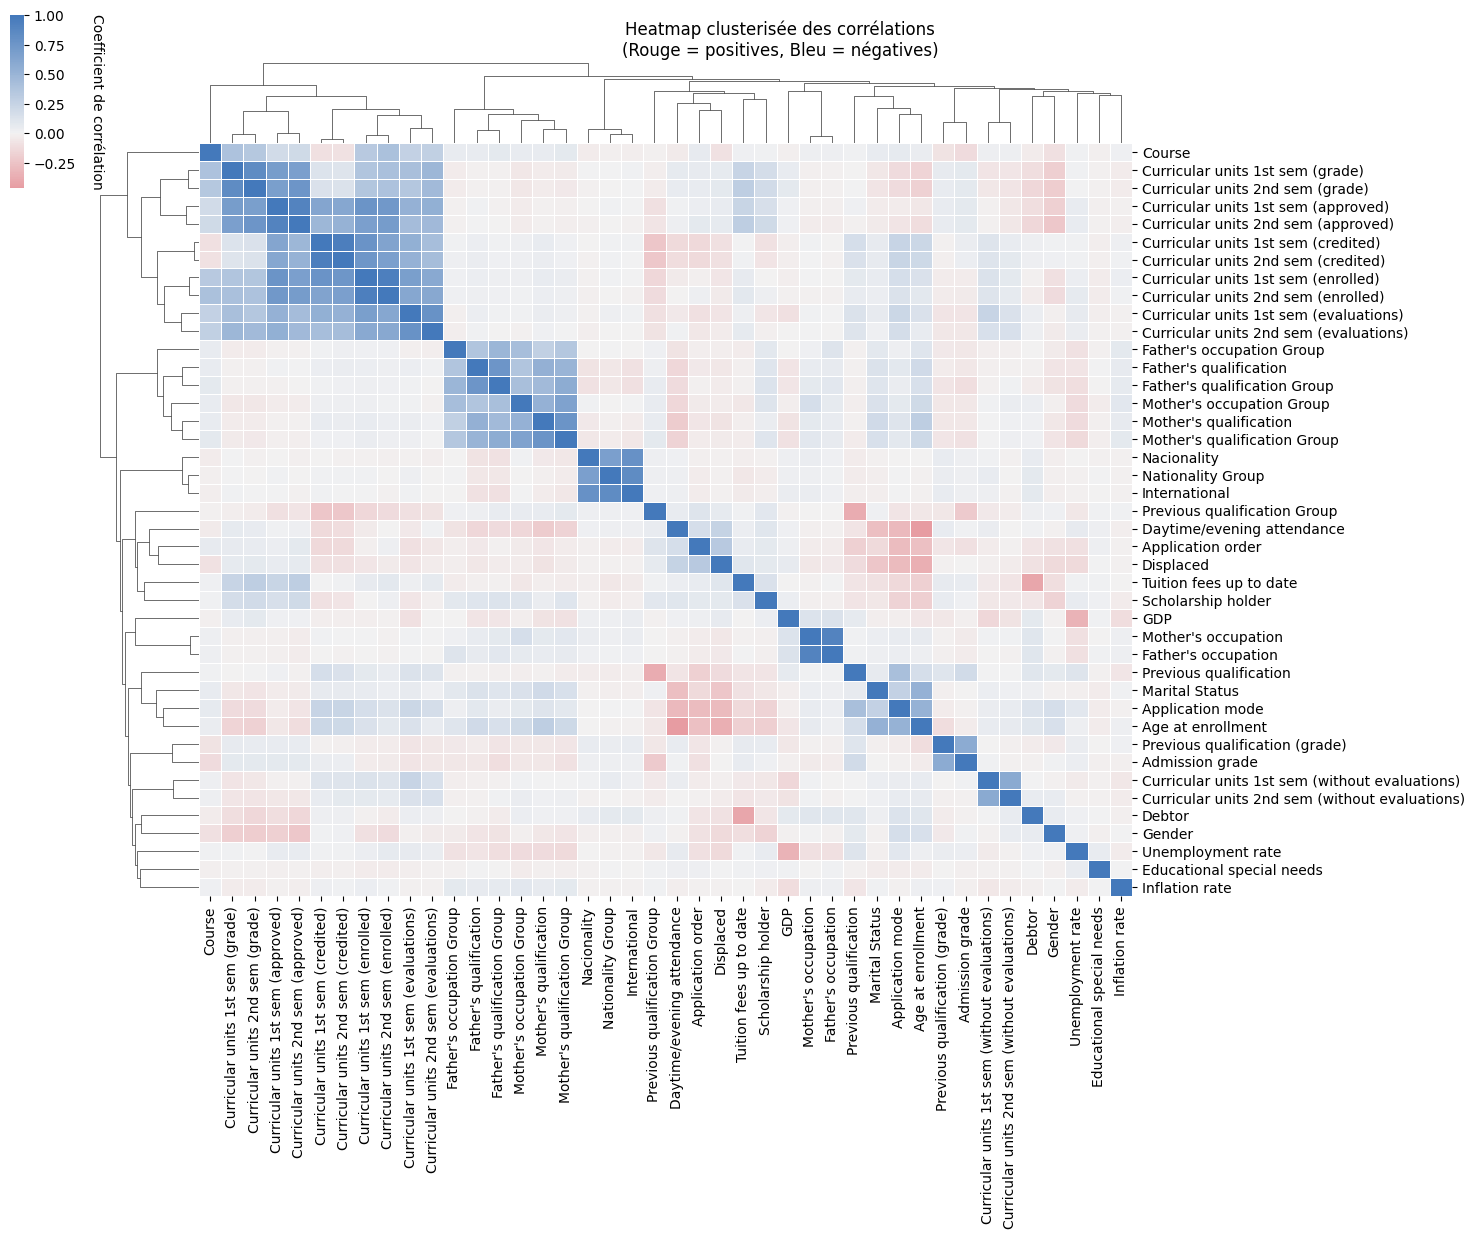

In [ ]:
### Matrice de corrélation complète avec heatmap clusterisée ###

import os
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage
import warnings
warnings.filterwarnings('ignore')

# --- Définition du dossier et création si nécessaire ---
data_folder = Path("data")
data_folder.mkdir(parents=True, exist_ok=True)  # Crée le dossier 'data' s'il n'existe pas

# --- Chargement des données depuis le fichier CSV ---
file_path = data_folder / "data_update.csv"
df = pd.read_csv(file_path, sep=';')

# --- Sélection des colonnes numériques uniquement ---
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df_numeric = df[num_cols]

# --- Calcul de la matrice de corrélation ---
corr_matrix = df_numeric.corr()

# --- Sauvegarde de la matrice complète dans le dossier data ---
corr_matrix.to_csv(data_folder / "correlation_matrix.csv")

# --- Extraction des corrélations fortes (|r| ≥ 0.8) ---
strong_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) >= 0.8:
            strong_pairs.append((corr_matrix.index[i], corr_matrix.columns[j], val))

# --- Affichage des paires fortement corrélées dans la console ---
print("Corrélations fortes (|r| ≥ 0.8) :")
for var1, var2, val in strong_pairs:
    sign = "🔴" if val > 0 else "🔵"  # Rouge si positive, bleu sinon
    print(f"{sign} {var1} ↔ {var2} : {val:.4f}")

# --- Création de la palette rouge-blanc-bleu pour heatmap ---
cmap = sns.diverging_palette(10, 250, as_cmap=True)

# --- Calcul du clustering hiérarchique pour ordonner les variables ---
link_rows = linkage(corr_matrix, method='average')
link_cols = linkage(corr_matrix.T, method='average')

# --- Génération et affichage de la heatmap clusterisée complète ---
g = sns.clustermap(
    corr_matrix,
    row_linkage=link_rows,
    col_linkage=link_cols,
    cmap=cmap,
    center=0,
    linewidths=0.5,
    figsize=(14, 12),
    cbar_kws={'label': 'Coefficient de corrélation'},
    dendrogram_ratio=(0.1, 0.1),
)

# Récupérer la position actuelle de la colorbar (BBox)
pos = g.cax.get_position()

# Déplacer la colorbar horizontalement (x0, x1) ou verticalement (y0, y1)
# Exemple pour décaler vers la gauche (plus petit x0 et x1)
new_pos = [pos.x0 - 0.07, pos.y0 + 0.08, pos.width, pos.height]

# Appliquer la nouvelle position
g.cax.set_position(new_pos)

# Modifier la taille de la police du label de la colorbar
g.cax.set_ylabel('Coefficient de corrélation', fontsize=10, rotation=270, labelpad=20)

# Modifier la taille et le ratio de la colorbar (l'axe lui-même)
pos = g.cax.get_position()
g.cax.set_position([pos.x0, pos.y0, pos.width * 0.2, pos.height * 0.8])  # Multiplier taille

plt.suptitle('Heatmap clusterisée des corrélations\n(Rouge = positives, Bleu = négatives)', y=1.02)
plt.show()


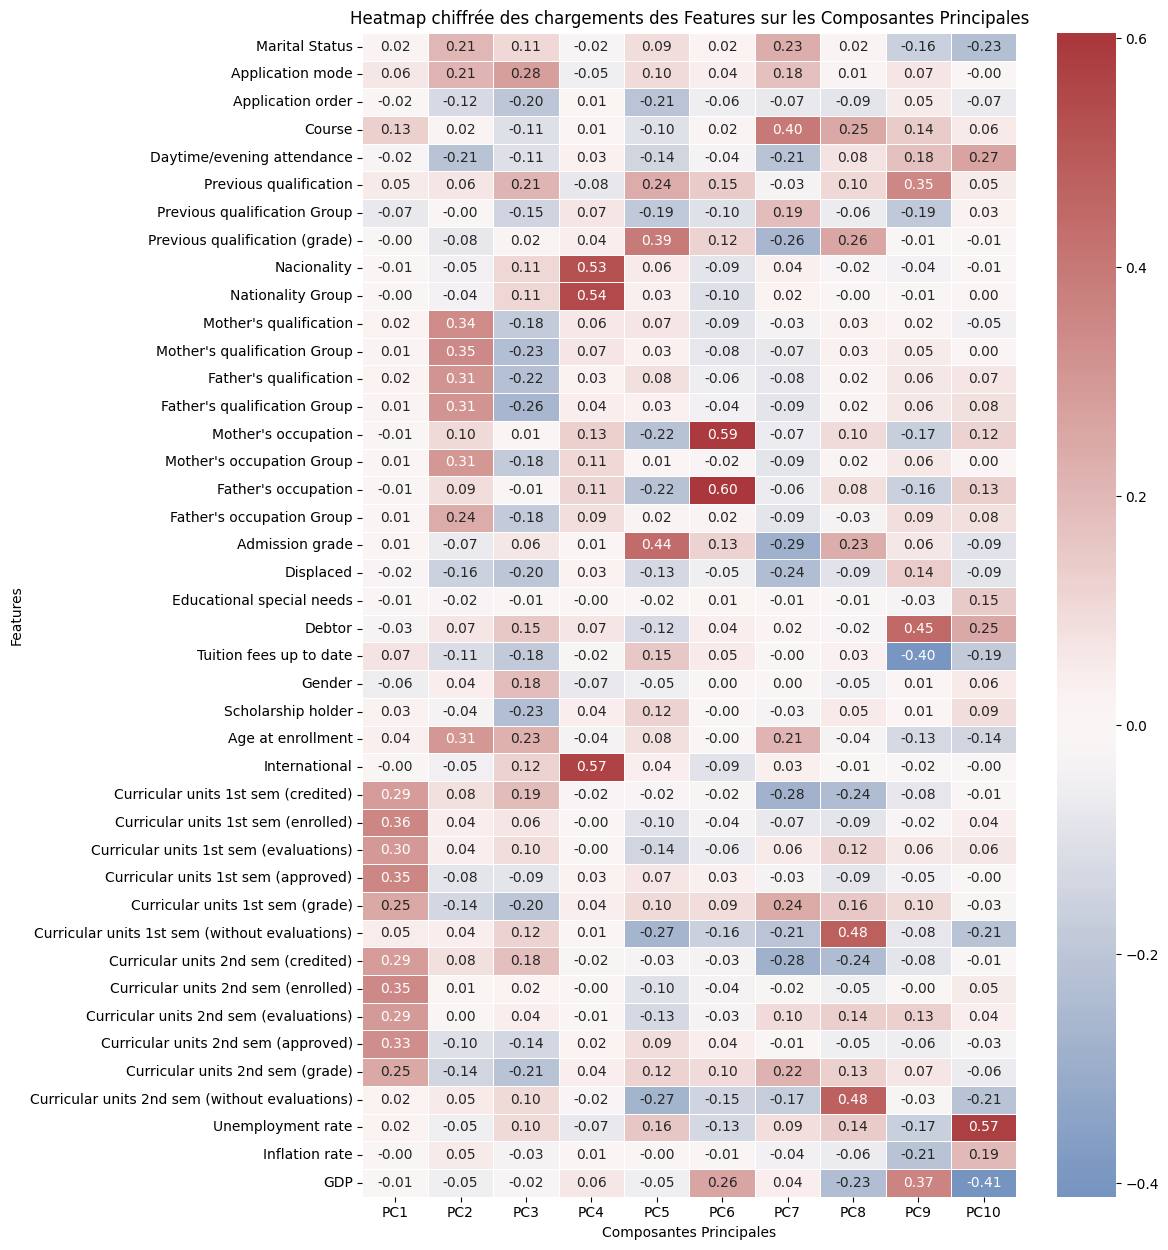


Composante PC1 :
 - Curricular units 1st sem (enrolled): 0.358
 - Curricular units 1st sem (approved): 0.354
 - Curricular units 2nd sem (enrolled): 0.348
 - Curricular units 2nd sem (approved): 0.332
 - Curricular units 1st sem (evaluations): 0.299

Composante PC2 :
 - Mother's qualification Group: 0.349
 - Mother's qualification: 0.342
 - Father's qualification Group: 0.313
 - Father's qualification: 0.312
 - Mother's occupation Group: 0.307

Composante PC3 :
 - Application mode: 0.283
 - Father's qualification Group: -0.259
 - Scholarship holder: -0.233
 - Mother's qualification Group: -0.231
 - Age at enrollment: 0.227

Composante PC4 :
 - International: 0.567
 - Nationality Group: 0.543
 - Nacionality: 0.527
 - Mother's occupation: 0.132
 - Father's occupation: 0.115

Composante PC5 :
 - Admission grade: 0.439
 - Previous qualification (grade): 0.393
 - Curricular units 2nd sem (without evaluations): -0.274
 - Curricular units 1st sem (without evaluations): -0.272
 - Previous qua

In [44]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# --- Chargement des données ---
data_folder = "data"
data_path = f"{data_folder}/data_update.csv"
df = pd.read_csv(data_path, sep=';')

# --- Sélection des variables numériques ---
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df_numeric = df[num_cols].copy()

# --- Standardisation des variables (centrer/réduire) ---
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_numeric)

# --- PCA avec sklearn ---
n_components = min(len(num_cols), 10)  # limite à 10 composantes ou nombre de features
pca = PCA(n_components=n_components)
pca_result = pca.fit_transform(data_scaled)

# --- Création dataframe des composantes principales (chargements) ---
loadings = pd.DataFrame(
    pca.components_.T,  # Transposer pour avoir features en lignes
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=num_cols
)

# --- Heatmap chiffrée (valeurs précises sur chaque case) ---
plt.figure(figsize=(12, max(6, len(num_cols)*0.3)))
sns.heatmap(loadings, cmap='vlag', center=0, annot=True, fmt='.2f', linewidths=0.5)
plt.title('Heatmap chiffrée des chargements des Features sur les Composantes Principales')
plt.xlabel('Composantes Principales')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# --- Extraction des features les plus importantes par composante principale ---
# Définition : top 5 features en valeur absolue par composante

def top_features_per_pc(loadings_df, top_n=5):
    tops = {}
    for pc in loadings_df.columns:
        sorted_features = loadings_df[pc].abs().sort_values(ascending=False).head(top_n).index
        tops[pc] = list(zip(sorted_features, loadings_df.loc[sorted_features, pc]))
    return tops

important_features = top_features_per_pc(loadings)

# --- Affichage des features clés ---
for pc, feats in important_features.items():
    print(f"\nComposante {pc} :")
    for feat, val in feats:
        print(f" - {feat}: {val:.3f}")


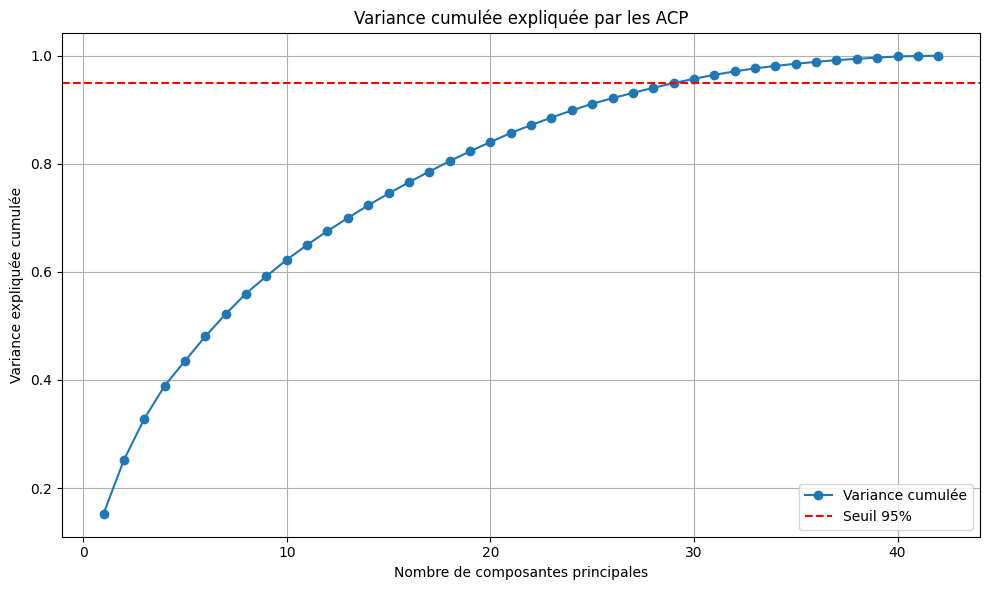

Nombre de composantes nécessaires pour expliquer 95% de la variance : 30


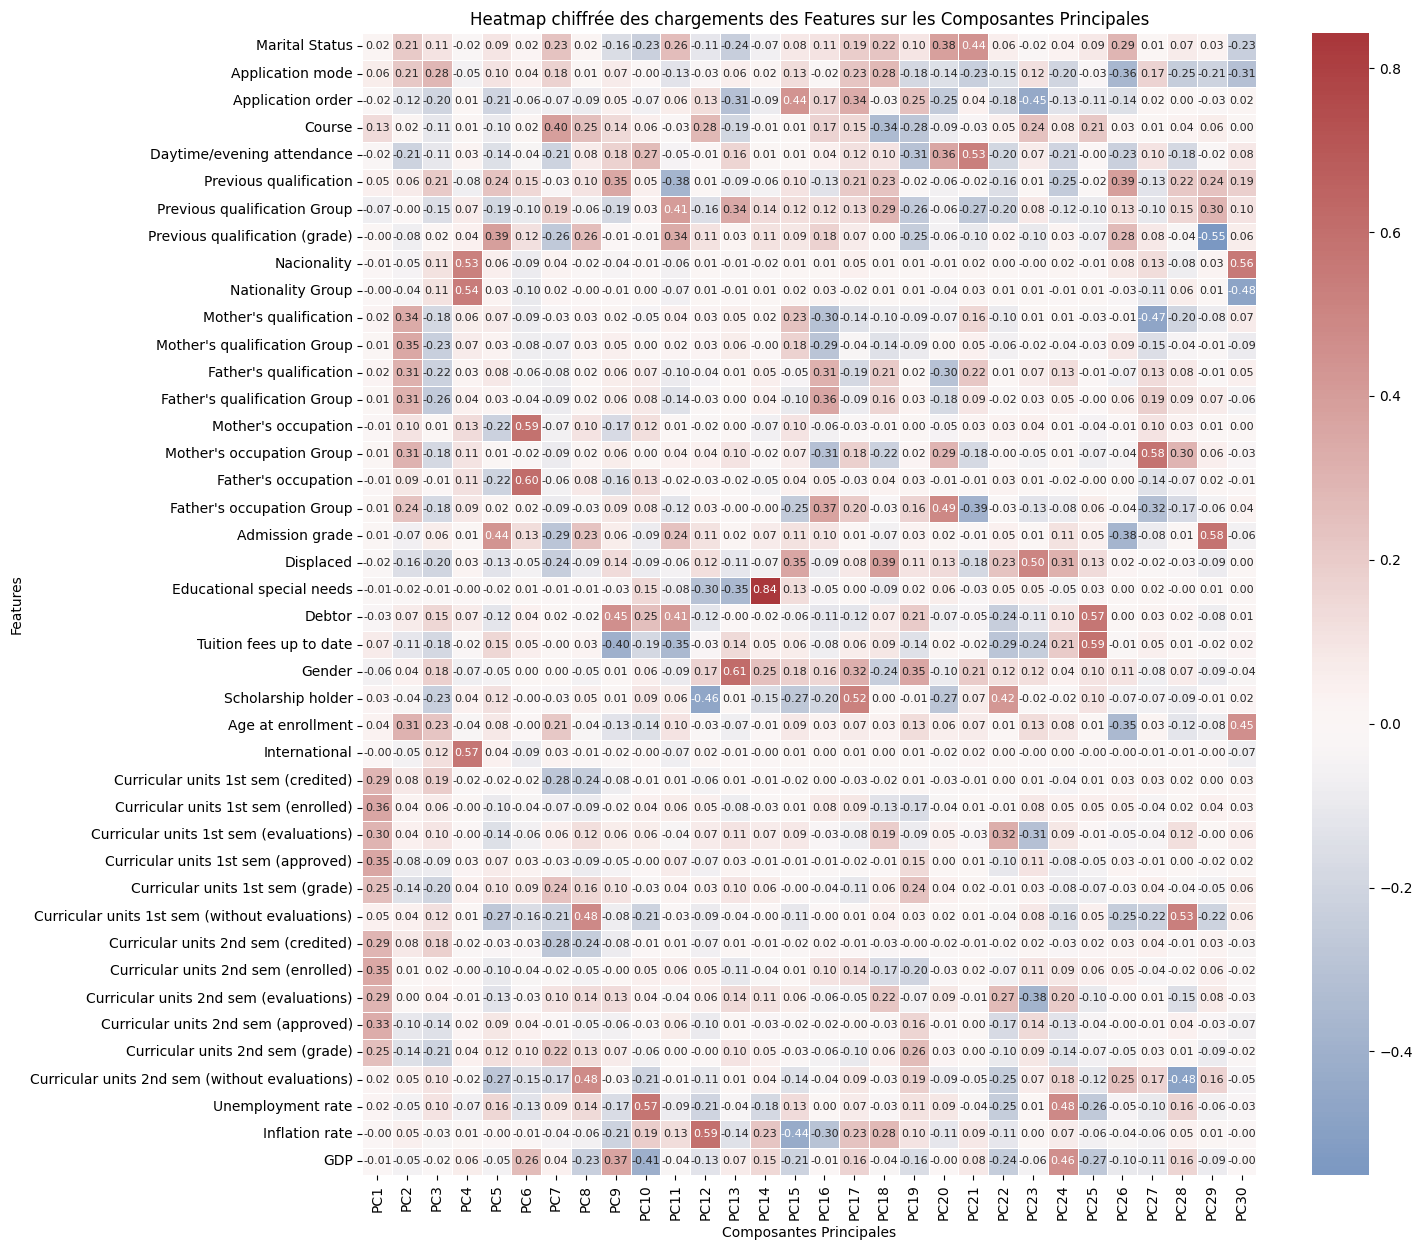


Composante PC1 :
 - Curricular units 1st sem (enrolled): 0.358
 - Curricular units 1st sem (approved): 0.354
 - Curricular units 2nd sem (enrolled): 0.348
 - Curricular units 2nd sem (approved): 0.332
 - Curricular units 1st sem (evaluations): 0.299

Composante PC2 :
 - Mother's qualification Group: 0.349
 - Mother's qualification: 0.342
 - Father's qualification Group: 0.313
 - Father's qualification: 0.312
 - Mother's occupation Group: 0.307

Composante PC3 :
 - Application mode: 0.283
 - Father's qualification Group: -0.259
 - Scholarship holder: -0.233
 - Mother's qualification Group: -0.231
 - Age at enrollment: 0.227

Composante PC4 :
 - International: 0.567
 - Nationality Group: 0.543
 - Nacionality: 0.527
 - Mother's occupation: 0.132
 - Father's occupation: 0.115

Composante PC5 :
 - Admission grade: 0.439
 - Previous qualification (grade): 0.393
 - Curricular units 2nd sem (without evaluations): -0.274
 - Curricular units 1st sem (without evaluations): -0.272
 - Previous qua

In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# --- Chargement des données ---
data_folder = "data"
data_path = f"{data_folder}/data_update.csv"
df = pd.read_csv(data_path, sep=';')

# --- Sélection des variables numériques ---
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df_numeric = df[num_cols].copy()

# --- Standardisation des variables ---
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_numeric)

# --- PCA avec sklearn ---
pca = PCA()
pca_result = pca.fit_transform(data_scaled)

# --- Variance expliquée par chaque composante ---
explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

# --- Graphique de la variance expliquée cumulée ---
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o', label='Variance cumulée')
plt.axhline(y=0.95, color='r', linestyle='--', label='Seuil 95%')
plt.xlabel('Nombre de composantes principales')
plt.ylabel('Variance expliquée cumulée')
plt.title('Variance cumulée expliquée par les ACP')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Affichage du nombre de composantes nécessaires pour atteindre 95% ---
n_95 = np.argmax(cum_var >= 0.95) + 1
print(f"Nombre de composantes nécessaires pour expliquer 95% de la variance : {n_95}")

# --- PCA avec le nombre optimal de composantes ---
pca_opt = PCA(n_components=n_95)
pca_result_opt = pca_opt.fit_transform(data_scaled)

# --- Création dataframe des chargements ---
loadings = pd.DataFrame(
    pca_opt.components_.T,
    columns=[f'PC{i+1}' for i in range(n_95)],
    index=num_cols
)

# --- Heatmap chiffrée des chargements ---
plt.figure(figsize=(15, max(8, len(num_cols)*0.3)))  # Fenêtre plus large et haute
sns.heatmap(
    loadings,
    cmap='vlag',
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    annot_kws={'size': 8}  # Taille réduite des chiffres dans les cases
)
plt.title('Heatmap chiffrée des chargements des Features sur les Composantes Principales')
plt.xlabel('Composantes Principales')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# --- Extraction des features les plus importantes par composante principale ---
def top_features_per_pc(loadings_df, top_n=5):
    tops = {}
    for pc in loadings_df.columns:
        sorted_features = loadings_df[pc].abs().sort_values(ascending=False).head(top_n).index
        tops[pc] = list(zip(sorted_features, loadings_df.loc[sorted_features, pc]))
    return tops

important_features = top_features_per_pc(loadings)

# --- Affichage des features clés ---
for pc, feats in important_features.items():
    print(f"\nComposante {pc} :")
    for feat, val in feats:
        print(f" - {feat}: {val:.3f}")
